### Project-2
### Applying:EDA(Exploratory Data Analysis) 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cln_df = pd.read_excel("Cleaned_dataset.xlsx")

In [4]:
cln_df=pd.read_excel("Cleaned_dataset.xlsx")

In [5]:
cln_df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [6]:
cln_df['Month']=cln_df['Date'].dt.to_period("M")
monthly=(cln_df.groupby("Month").agg(
    TotalOrders=('OrderID','nunique'),
    UniqueCustomer=('CustomerID','nunique'),
    TotalOrder_Value=('TotalPrice','sum'),
    AverageOrderValue=("TotalPrice", "mean"),
        MedianOrderValue=("TotalPrice", "median"),
    Total_Quantity=('Quantity','sum')
    ).reset_index()
)


In [7]:
monthly.nlargest(5,"TotalOrder_Value")

,Month,TotalOrders,UniqueCustomer,TotalOrder_Value,AverageOrderValue,MedianOrderValue,Total_Quantity
17,2024-06,53,53,68068.54,1284.312075,1159.10,166
4,2023-05,49,49,63836.84,1302.792653,1248.32,148
0,2023-01,47,47,56685.75,1206.079787,1067.62,146
7,2023-08,51,51,54352.14,1065.728235,889.68,174
29,2025-06,49,49,53047.40,1082.600000,929.00,146


In [8]:
monthly_status = (
    cln_df.pivot_table(
        index="Month",
        columns="OrderStatus",
        values="OrderID",
        aggfunc="nunique",
        fill_value=0
    )
    .reset_index()
)

monthly = monthly.merge(monthly_status, on="Month", how="left")

In [9]:
monthly

,Month,TotalOrders,UniqueCustomer,TotalOrder_Value,AverageOrderValue,MedianOrderValue,Total_Quantity,Cancelled,Delivered,Pending,Returned,Shipped
0,2023-01,47,47,56685.75,1206.079787,1067.620,146,10,4,18,8,7
1,2023-02,37,37,40117.66,1084.261081,850.060,102,9,4,8,11,5
2,2023-03,43,43,48609.37,1130.450465,1039.560,126,13,6,8,10,6
3,2023-04,31,31,27751.71,895.216452,618.680,84,5,6,6,6,8
4,2023-05,49,49,63836.84,1302.792653,1248.320,148,12,10,9,8,10
5,2023-06,45,45,49500.19,1100.004222,1010.130,146,9,8,5,12,11
6,2023-07,44,44,42820.66,973.196818,670.955,119,9,11,14,3,7
7,2023-08,51,51,54352.14,1065.728235,889.680,174,11,9,9,13,9
8,2023-09,29,29,29526.67,1018.161034,824.280,86,7,3,9,7,3
9,2023-10,47,47,52607.85,1119.315957,977.800,150,7,17,5,7,11


In [10]:
monthly["DeliveryRate"] = (
    monthly["Delivered"] / monthly["TotalOrders"] * 100
)

monthly["CancellationRate"] = (
    monthly["Cancelled"] / monthly["TotalOrders"] * 100
)

monthly["ReturnRate"] = (
    monthly["Returned"] / monthly["TotalOrders"] * 100
)

In [11]:
monthly = monthly.round({
    "TotalOrderValue": 2,
    "AverageOrderValue": 2,
    "MedianOrderValue": 2,
    "DeliveryRate": 2,
    "CancellationRate": 2,
    "ReturnRate": 2
})

In [12]:
monthly

,Month,TotalOrders,UniqueCustomer,TotalOrder_Value,AverageOrderValue,MedianOrderValue,Total_Quantity,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate
0,2023-01,47,47,56685.75,1206.08,1067.62,146,10,4,18,8,7,8.51,21.28,17.02
1,2023-02,37,37,40117.66,1084.26,850.06,102,9,4,8,11,5,10.81,24.32,29.73
2,2023-03,43,43,48609.37,1130.45,1039.56,126,13,6,8,10,6,13.95,30.23,23.26
3,2023-04,31,31,27751.71,895.22,618.68,84,5,6,6,6,8,19.35,16.13,19.35
4,2023-05,49,49,63836.84,1302.79,1248.32,148,12,10,9,8,10,20.41,24.49,16.33
5,2023-06,45,45,49500.19,1100.00,1010.13,146,9,8,5,12,11,17.78,20.00,26.67
6,2023-07,44,44,42820.66,973.20,670.96,119,9,11,14,3,7,25.00,20.45,6.82
7,2023-08,51,51,54352.14,1065.73,889.68,174,11,9,9,13,9,17.65,21.57,25.49
8,2023-09,29,29,29526.67,1018.16,824.28,86,7,3,9,7,3,10.34,24.14,24.14
9,2023-10,47,47,52607.85,1119.32,977.80,150,7,17,5,7,11,36.17,14.89,14.89


In [13]:
monthly.nlargest(5, "Total_Quantity")
monthly.nlargest(5, "CancellationRate")
monthly.nlargest(5, "DeliveryRate")
monthly.nlargest(5, "ReturnRate")

,Month,TotalOrders,UniqueCustomer,TotalOrder_Value,AverageOrderValue,MedianOrderValue,Total_Quantity,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate
11,2023-12,46,46,43754.73,951.19,618.78,129,6,5,14,14,7,10.87,13.04,30.43
1,2023-02,37,37,40117.66,1084.26,850.06,102,9,4,8,11,5,10.81,24.32,29.73
16,2024-05,34,34,27909.11,820.86,616.07,95,4,6,6,10,8,17.65,11.76,29.41
27,2025-04,32,32,31821.20,994.41,744.02,89,13,5,2,9,3,15.62,40.62,28.12
15,2024-04,50,50,49613.14,992.26,722.12,147,12,12,9,14,3,24.00,24.00,28.00


<Axes: xlabel='Month'>

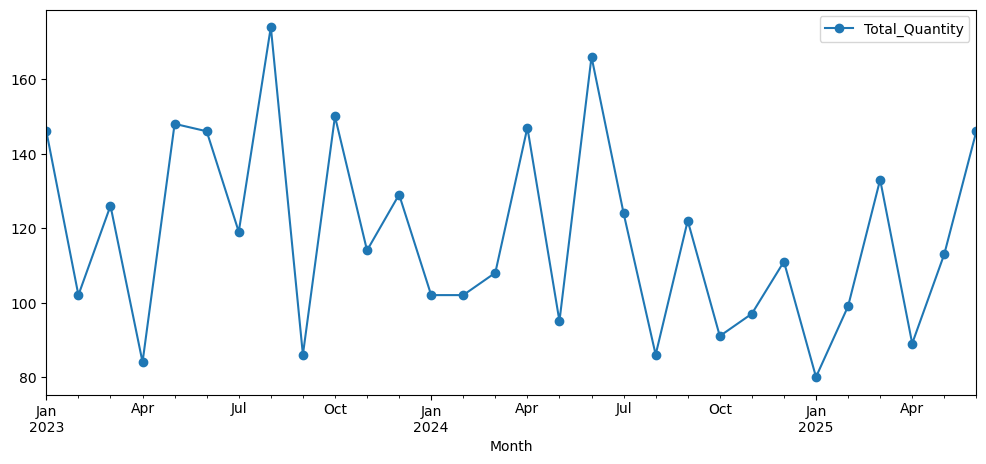

In [14]:
monthly.plot(
    x="Month",
    y="Total_Quantity",
    kind="line",
    marker="o",
    figsize=(12, 5)
)

In [15]:
monthly.columns

Index(['Month', 'TotalOrders', 'UniqueCustomer', 'TotalOrder_Value',
       'AverageOrderValue', 'MedianOrderValue', 'Total_Quantity', 'Cancelled',
       'Delivered', 'Pending', 'Returned', 'Shipped', 'DeliveryRate',
       'CancellationRate', 'ReturnRate'],
      dtype='object')

In [16]:
monthly.sort_values("Total_Quantity",ascending=False).head(2)

,Month,TotalOrders,UniqueCustomer,TotalOrder_Value,AverageOrderValue,MedianOrderValue,Total_Quantity,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate
7,2023-08,51,51,54352.14,1065.73,889.68,174,11,9,9,13,9,17.65,21.57,25.49
17,2024-06,53,53,68068.54,1284.31,1159.10,166,11,11,9,9,13,20.75,20.75,16.98


### Product Performance

In [17]:
product_summary = (
    cln_df.groupby("Product")
    .agg(
        TotalOrders=("OrderID", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        TotalOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        MedianOrderValue=("TotalPrice", "median")
    )
    .reset_index()
)

In [18]:
print(product_summary)

   Product  TotalOrders  TotalQuantity  TotalOrderValue  AverageOrderValue  \
0    Chair          178            562        195620.11        1098.989382   
1     Desk          170            508        167459.93         985.058412   
2   Laptop          173            535        192126.56        1110.558150   
3  Monitor          163            480        175651.41        1077.616012   
4    Phone          156            411        151722.39         972.579423   
5  Printer          181            542        195612.61        1080.732652   
6   Tablet          179            497        186568.95        1042.284637   

   MedianOrderValue  
0           928.575  
1           784.390  
2           915.640  
3           853.400  
4           691.715  
5           857.400  
6           786.660  


In [19]:
product_summary=product_summary.sort_values(by=['TotalQuantity'],ascending=False)

In [20]:
product_summary

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue
0,Chair,178,562,195620.11,1098.989382,928.575
5,Printer,181,542,195612.61,1080.732652,857.400
2,Laptop,173,535,192126.56,1110.558150,915.640
1,Desk,170,508,167459.93,985.058412,784.390
6,Tablet,179,497,186568.95,1042.284637,786.660
3,Monitor,163,480,175651.41,1077.616012,853.400
4,Phone,156,411,151722.39,972.579423,691.715


In [21]:
product_summary.sort_values(by=['TotalOrderValue'],ascending=False)
product_summary

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue
0,Chair,178,562,195620.11,1098.989382,928.575
5,Printer,181,542,195612.61,1080.732652,857.400
2,Laptop,173,535,192126.56,1110.558150,915.640
1,Desk,170,508,167459.93,985.058412,784.390
6,Tablet,179,497,186568.95,1042.284637,786.660
3,Monitor,163,480,175651.41,1077.616012,853.400
4,Phone,156,411,151722.39,972.579423,691.715


In [22]:
delivered_df = cln_df[cln_df["OrderStatus"] == "Delivered"]

delivered_monthly = delivered_df.groupby("Month").agg(
    DeliveredOrders=("OrderID", "nunique"),
    DeliveredOrderValue=("TotalPrice", "sum"),
    DeliveredAOV=("TotalPrice", "mean")
).reset_index()

In [23]:
delivered_monthly

,Month,DeliveredOrders,DeliveredOrderValue,DeliveredAOV
0,2023-01,4,5316.98,1329.245000
1,2023-02,4,2901.42,725.355000
2,2023-03,6,4624.18,770.696667
3,2023-04,6,6162.55,1027.091667
4,2023-05,10,12171.05,1217.105000
5,2023-06,8,9760.62,1220.077500
6,2023-07,11,13976.36,1270.578182
7,2023-08,9,11827.45,1314.161111
8,2023-09,3,2275.75,758.583333
9,2023-10,17,22231.49,1307.734706


In [24]:
product_status = (
    cln_df.pivot_table(
        index="Product",
        columns="OrderStatus",
        values="OrderID",
        aggfunc="nunique",
        fill_value=0
    )
    .reset_index()
)

product_status

OrderStatus,Product,Cancelled,Delivered,Pending,Returned,Shipped
0,Chair,45,33,41,28,31
1,Desk,35,32,38,32,33
2,Laptop,35,40,30,39,29
3,Monitor,35,31,29,36,32
4,Phone,31,38,28,31,28
5,Printer,35,29,37,38,42
6,Tablet,34,28,34,43,40


In [25]:
product_analysis = product_summary.merge(
    product_status,
    on="Product",
    how="left"
)

In [26]:
product_analysis

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped
0,Chair,178,562,195620.11,1098.989382,928.575,45,33,41,28,31
1,Printer,181,542,195612.61,1080.732652,857.400,35,29,37,38,42
2,Laptop,173,535,192126.56,1110.558150,915.640,35,40,30,39,29
3,Desk,170,508,167459.93,985.058412,784.390,35,32,38,32,33
4,Tablet,179,497,186568.95,1042.284637,786.660,34,28,34,43,40
5,Monitor,163,480,175651.41,1077.616012,853.400,35,31,29,36,32
6,Phone,156,411,151722.39,972.579423,691.715,31,38,28,31,28


In [27]:
product_analysis["DeliveryRate"] = (
    product_analysis["Delivered"]
    / product_analysis["TotalOrders"]
    * 100
)

product_analysis["CancellationRate"] = (
    product_analysis["Cancelled"]
    / product_analysis["TotalOrders"]
    * 100
)

product_analysis["ReturnRate"] = (
    product_analysis["Returned"]
    / product_analysis["TotalOrders"]
    * 100
)

product_analysis = product_analysis.round(2)

In [28]:
product_analysis

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate
0,Chair,178,562,195620.11,1098.99,928.58,45,33,41,28,31,18.54,25.28,15.73
1,Printer,181,542,195612.61,1080.73,857.40,35,29,37,38,42,16.02,19.34,20.99
2,Laptop,173,535,192126.56,1110.56,915.64,35,40,30,39,29,23.12,20.23,22.54
3,Desk,170,508,167459.93,985.06,784.39,35,32,38,32,33,18.82,20.59,18.82
4,Tablet,179,497,186568.95,1042.28,786.66,34,28,34,43,40,15.64,18.99,24.02
5,Monitor,163,480,175651.41,1077.62,853.40,35,31,29,36,32,19.02,21.47,22.09
6,Phone,156,411,151722.39,972.58,691.71,31,38,28,31,28,24.36,19.87,19.87


In [29]:
product_analysis["StatusTotal"] = product_analysis[
    ["Cancelled", "Delivered", "Pending", "Returned", "Shipped"]
].sum(axis=1)

product_analysis["StatusCheck"] = (
    product_analysis["StatusTotal"]
    == product_analysis["TotalOrders"]
)

product_analysis["StatusCheck"].all()

np.True_

In [30]:
product_analysis.nlargest(3, "TotalQuantity")

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusTotal,StatusCheck
0,Chair,178,562,195620.11,1098.99,928.58,45,33,41,28,31,18.54,25.28,15.73,178,True
1,Printer,181,542,195612.61,1080.73,857.40,35,29,37,38,42,16.02,19.34,20.99,181,True
2,Laptop,173,535,192126.56,1110.56,915.64,35,40,30,39,29,23.12,20.23,22.54,173,True


In [31]:
product_analysis.nlargest(3, "TotalOrderValue")

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusTotal,StatusCheck
0,Chair,178,562,195620.11,1098.99,928.58,45,33,41,28,31,18.54,25.28,15.73,178,True
1,Printer,181,542,195612.61,1080.73,857.40,35,29,37,38,42,16.02,19.34,20.99,181,True
2,Laptop,173,535,192126.56,1110.56,915.64,35,40,30,39,29,23.12,20.23,22.54,173,True


In [32]:
product_analysis.nlargest(3, "DeliveryRate")

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusTotal,StatusCheck
6,Phone,156,411,151722.39,972.58,691.71,31,38,28,31,28,24.36,19.87,19.87,156,True
2,Laptop,173,535,192126.56,1110.56,915.64,35,40,30,39,29,23.12,20.23,22.54,173,True
5,Monitor,163,480,175651.41,1077.62,853.40,35,31,29,36,32,19.02,21.47,22.09,163,True


In [33]:
product_analysis.nlargest(3, "CancellationRate")

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusTotal,StatusCheck
0,Chair,178,562,195620.11,1098.99,928.58,45,33,41,28,31,18.54,25.28,15.73,178,True
5,Monitor,163,480,175651.41,1077.62,853.40,35,31,29,36,32,19.02,21.47,22.09,163,True
3,Desk,170,508,167459.93,985.06,784.39,35,32,38,32,33,18.82,20.59,18.82,170,True


In [34]:
product_analysis.nlargest(3, "ReturnRate")

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusTotal,StatusCheck
4,Tablet,179,497,186568.95,1042.28,786.66,34,28,34,43,40,15.64,18.99,24.02,179,True
2,Laptop,173,535,192126.56,1110.56,915.64,35,40,30,39,29,23.12,20.23,22.54,173,True
5,Monitor,163,480,175651.41,1077.62,853.40,35,31,29,36,32,19.02,21.47,22.09,163,True


In [35]:
delivered_value = (
    cln_df[cln_df["OrderStatus"] == "Delivered"]
    .groupby("Product")
    .agg(
        DeliveredOrderValue=("TotalPrice", "sum"),
        DeliveredQuantity=("Quantity", "sum")
    )
    .reset_index()
)

product_analysis = product_analysis.merge(
    delivered_value,
    on="Product",
    how="left"
).fillna(0)

In [36]:
product_analysis

,Product,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,MedianOrderValue,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusTotal,StatusCheck,DeliveredOrderValue,DeliveredQuantity
0,Chair,178,562,195620.11,1098.99,928.58,45,33,41,28,31,18.54,25.28,15.73,178,True,31465.83,105
1,Printer,181,542,195612.61,1080.73,857.40,35,29,37,38,42,16.02,19.34,20.99,181,True,38054.73,88
2,Laptop,173,535,192126.56,1110.56,915.64,35,40,30,39,29,23.12,20.23,22.54,173,True,40714.43,121
3,Desk,170,508,167459.93,985.06,784.39,35,32,38,32,33,18.82,20.59,18.82,170,True,24225.78,94
4,Tablet,179,497,186568.95,1042.28,786.66,34,28,34,43,40,15.64,18.99,24.02,179,True,31794.52,85
5,Monitor,163,480,175651.41,1077.62,853.40,35,31,29,36,32,19.02,21.47,22.09,163,True,35999.62,96
6,Phone,156,411,151722.39,972.58,691.71,31,38,28,31,28,24.36,19.87,19.87,156,True,40345.41,101


In [37]:
customer_summary = (
    cln_df.groupby("CustomerID")
    .agg(
        TotalOrders=("OrderID", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        TotalOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        FirstOrderDate=("Date", "min"),
        LastOrderDate=("Date", "max")
    )
    .reset_index()
    .round(2)
)

In [38]:
customer_summary

,CustomerID,TotalOrders,TotalQuantity,TotalOrderValue,AverageOrderValue,FirstOrderDate,LastOrderDate
0,C10002,1,3,1470.03,1470.03,2023-10-16,2023-10-16
1,C10054,1,2,153.48,153.48,2024-10-14,2024-10-14
2,C10126,1,2,1349.80,1349.80,2023-06-18,2023-06-18
3,C10154,1,4,1303.04,1303.04,2024-07-29,2024-07-29
4,C10211,1,5,635.90,635.90,2024-05-09,2024-05-09
...,...,...,...,...,...,...,...
1184,C99589,1,1,641.39,641.39,2025-06-24,2025-06-24
1185,C99683,1,5,1663.20,1663.20,2025-01-23,2025-01-23
1186,C99775,1,4,1654.84,1654.84,2023-09-05,2023-09-05
1187,C99879,1,3,821.88,821.88,2024-03-13,2024-03-13


In [39]:
customer_summary["CustomerType"] = np.where(
    customer_summary["TotalOrders"] > 1,
    "Repeat",
    "One-time"
)

customer_summary["CustomerType"].value_counts()

CustomerType
One-time    1178
Repeat        11
Name: count, dtype: int64

In [40]:
delivered_customer = (
    cln_df[cln_df["OrderStatus"] == "Delivered"]
    .groupby("CustomerID")
    .agg(
        DeliveredOrders=("OrderID", "nunique"),
        DeliveredOrderValue=("TotalPrice", "sum"),
        DeliveredQuantity=("Quantity", "sum")
    )
    .reset_index()
)

In [41]:
delivered_customer["DeliveredOrders"].value_counts()

DeliveredOrders
1    231
Name: count, dtype: int64

In [42]:
customer_analysis = customer_summary.merge(
    delivered_customer,
    on="CustomerID",
    how="left"
)

delivered_columns = [
    "DeliveredOrders",
    "DeliveredOrderValue",
    "DeliveredQuantity"
]

customer_analysis[delivered_columns] = (
    customer_analysis[delivered_columns].fillna(0)
)

In [43]:
customer_analysis[delivered_columns]

,DeliveredOrders,DeliveredOrderValue,DeliveredQuantity
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
...,...,...,...
1184,0.0,0.0,0.0
1185,1.0,1663.2,5.0
1186,0.0,0.0,0.0
1187,0.0,0.0,0.0


In [44]:
customer_analysis.nlargest(
    10,
    "DeliveredOrderValue"
)[
    [
        "CustomerID",
        "TotalOrders",
        "DeliveredOrders",
        "DeliveredOrderValue",
        "DeliveredQuantity"
    ]
]

,CustomerID,TotalOrders,DeliveredOrders,DeliveredOrderValue,DeliveredQuantity
648,C57276,1,1.0,3456.40,5.0
781,C67260,1,1.0,3390.80,5.0
520,C47778,1,1.0,3334.00,5.0
599,C53464,1,1.0,3299.25,5.0
1028,C88029,1,1.0,3277.75,5.0
1050,C89979,1,1.0,3170.00,5.0
14,C11415,1,1.0,2876.20,5.0
566,C50415,1,1.0,2830.35,5.0
475,C43595,1,1.0,2807.40,5.0
52,C13366,1,1.0,2714.20,4.0


## Referral_Summary

In [45]:
referral_summary = (
    cln_df.groupby("ReferralSource")
    .agg(
        TotalOrders=("OrderID", "nunique"),
        TotalOrderValue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        TotalQuantity=("Quantity", "sum")
    )
    .reset_index()
)

In [46]:
cln_df["CouponUsed"] = np.where(
    cln_df["CouponCode"] == "NO_COUPON",
    "No Coupon",
    "Coupon Used"
)

coupon_summary = (
    cln_df.groupby("CouponUsed")
    .agg(
        TotalOrders=("OrderID", "nunique"),
        AverageOrderValue=("TotalPrice", "mean"),
        AverageQuantity=("Quantity", "mean")
    )
    .reset_index()
)

In [47]:
coupon_summary

,CouponUsed,TotalOrders,AverageOrderValue,AverageQuantity
0,Coupon Used,891,1057.643715,2.911336
1,No Coupon,309,1043.370259,3.045307


In [48]:
cln_df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month',
       'CouponUsed'],
      dtype='object')

## Payment Method Analysis

In [49]:
payment_summary=(cln_df.groupby("PaymentMethod")
.agg(
    TotalPayment=("TotalPrice","sum"),
    TotalOrders=("OrderID","nunique")
)
.reset_index()
.round(2)
)
payment_summary

,PaymentMethod,TotalPayment,TotalOrders
0,Cash,259786.29,246
1,Credit Card,263847.63,234
2,Debit Card,232361.18,232
3,Gift Card,246323.92,230
4,Online,262442.94,258


In [50]:
payment_status=(
    cln_df.pivot_table(
        index="PaymentMethod",
        columns="OrderStatus",
        values="OrderID",
        aggfunc="nunique",
        fill_value=0
    )
    .reset_index()
)
payment_status

OrderStatus,PaymentMethod,Cancelled,Delivered,Pending,Returned,Shipped
0,Cash,49,45,52,57,43
1,Credit Card,54,43,48,49,40
2,Debit Card,44,43,55,51,39
3,Gift Card,50,37,35,52,56
4,Online,53,63,47,38,57


In [51]:
payment_analysis=payment_summary.merge(
    payment_status,on="PaymentMethod", how="left"
)

In [52]:
payment_analysis["DeliveryRate"] = (
    payment_analysis["Delivered"]
    / payment_analysis["TotalOrders"] * 100
)

payment_analysis["CancellationRate"] = (
    payment_analysis["Cancelled"]
    / payment_analysis["TotalOrders"] * 100
)

payment_analysis["ReturnRate"] = (
    payment_analysis["Returned"]
    / payment_analysis["TotalOrders"] * 100
)

payment_analysis = payment_analysis.round(2)

In [53]:
status_columns = [
    "Cancelled", "Delivered", "Pending", "Returned", "Shipped"
]

payment_analysis["StatusCheck"] = (
    payment_analysis[status_columns].sum(axis=1)
    == payment_analysis["TotalOrders"]
)

payment_analysis["StatusCheck"].all()

np.True_

In [54]:
payment_analysis

,PaymentMethod,TotalPayment,TotalOrders,Cancelled,Delivered,Pending,Returned,Shipped,DeliveryRate,CancellationRate,ReturnRate,StatusCheck
0,Cash,259786.29,246,49,45,52,57,43,18.29,19.92,23.17,True
1,Credit Card,263847.63,234,54,43,48,49,40,18.38,23.08,20.94,True
2,Debit Card,232361.18,232,44,43,55,51,39,18.53,18.97,21.98,True
3,Gift Card,246323.92,230,50,37,35,52,56,16.09,21.74,22.61,True
4,Online,262442.94,258,53,63,47,38,57,24.42,20.54,14.73,True


## Distribution Analysis

In [55]:
cln_df[
    ["Quantity","UnitPrice","TotalPrice","ItemsInCart"]

].describe()

,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300,5.485000
std,1.407557,197.177146,819.856558,2.281983
min,1.000000,11.390000,11.390000,1.000000
25%,2.000000,186.062500,410.520000,4.000000
50%,3.000000,364.210000,823.615000,5.000000
75%,4.000000,521.570000,1578.475000,7.000000
max,5.000000,699.930000,3456.400000,10.000000


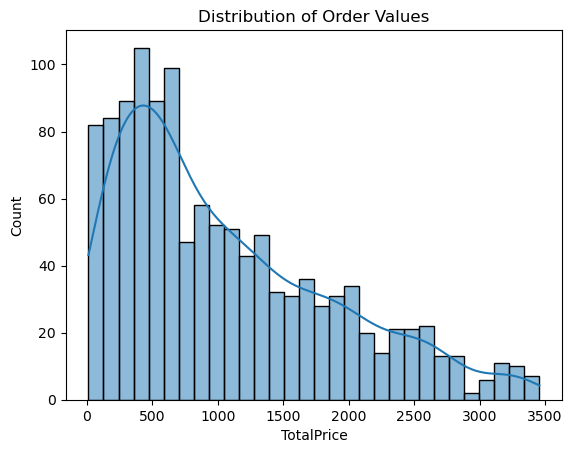

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(cln_df["TotalPrice"], bins=30, kde=True)
plt.title("Distribution of Order Values")
plt.show()

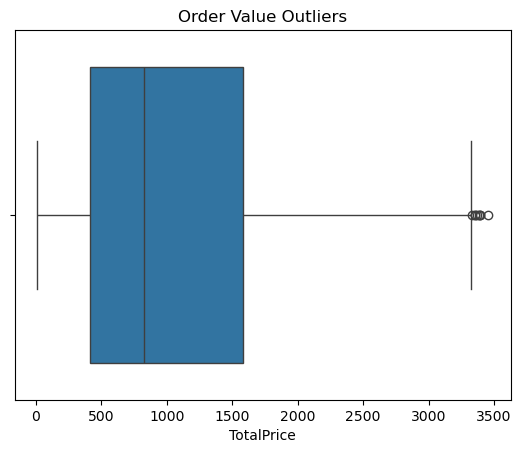

In [57]:
sns.boxplot(x=cln_df["TotalPrice"])
plt.title("Order Value Outliers")
plt.show()

In [58]:
Q1 = cln_df["TotalPrice"].quantile(0.25)
Q3 = cln_df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

order_outliers = cln_df[
    (cln_df["TotalPrice"] < lower_limit) |
    (cln_df["TotalPrice"] > upper_limit)
]

In [59]:
order_outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,CouponUsed
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,2023-03,Coupon Used
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,2024-07,Coupon Used
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,2023-02,Coupon Used
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO_COUPON,Facebook,3384.90,2023-11,No Coupon
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,2023-05,Coupon Used
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40,2023-08,Coupon Used
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00,2023-10,Coupon Used
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO_COUPON,Facebook,3390.95,2023-06,No Coupon
